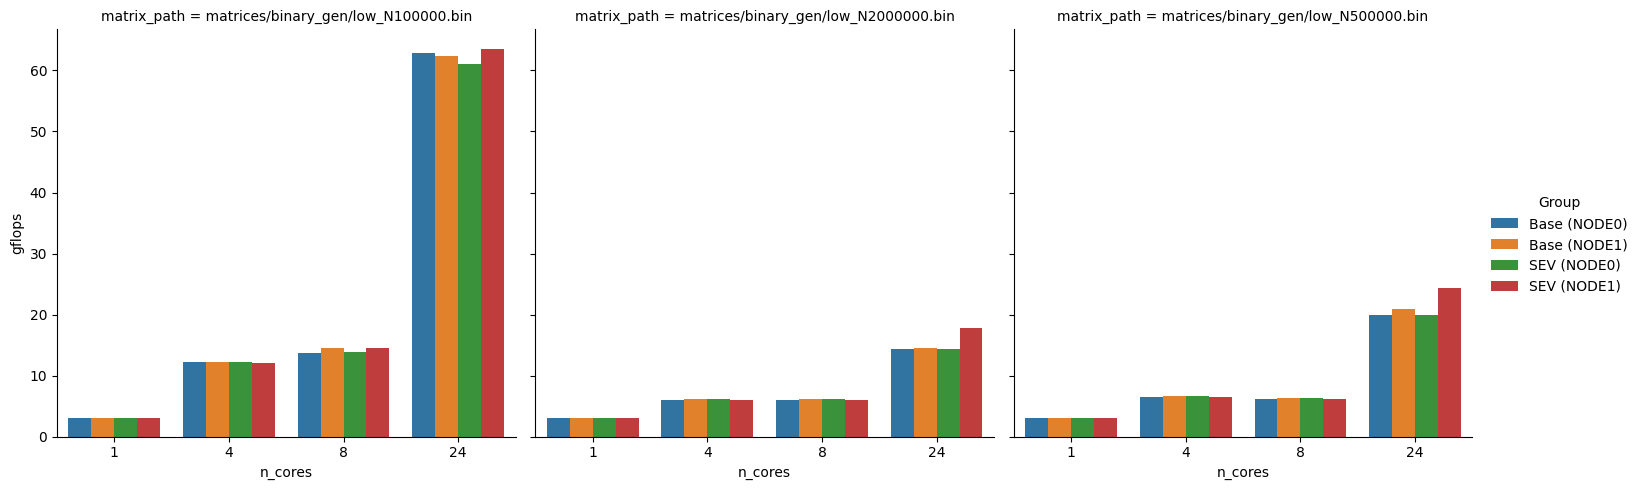

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Daten laden & Mergen
df = pd.concat([
    pd.read_csv('outputs/spmv_20260126_103517/spmv_results.csv').assign(env='Base'),
    pd.read_csv('outputs/spmv_20260126_110648/spmv_results.csv').assign(env='SEV')
])

df_med = df.groupby(['env', 'config', 'n_cores', 'matrix_path'])['gflops'].median().reset_index()

df_med['Group'] = df_med['env'] + " (" + df_med['config'] + ")"

sns.catplot( data=df_med, x='n_cores', y='gflops', hue='Group', col='matrix_path', kind='bar',)


In [9]:
# Daten pivotieren: 'env' wird zu Spaltenüberschriften
df_table = df_med.pivot(
    index=['matrix_path', 'config', 'n_cores'], 
    columns='env', 
    values='gflops'
).reset_index()

# Optional: Performance-Unterschied in Prozent berechnen
# (Wie viel langsamer/schneller ist SEV im Vergleich zu Base?)
df_table['diff_pct'] = ((df_table['SEV'] - df_table['Base']) / df_table['Base']) * 100

# Spalten sortieren für bessere Lesbarkeit
df_table = df_table.sort_values(['matrix_path', 'config', 'n_cores'])

# Tabelle anzeigen
print(df_table.to_string())

env                           matrix_path config  n_cores      Base       SEV   diff_pct
0     matrices/binary_gen/low_N100000.bin  NODE0        1   3.10134   3.10425   0.093830
1     matrices/binary_gen/low_N100000.bin  NODE0        4  12.16580  12.18380   0.147956
2     matrices/binary_gen/low_N100000.bin  NODE0        8  13.63460  13.93030   2.168747
3     matrices/binary_gen/low_N100000.bin  NODE0       24  62.90640  60.98800  -3.049610
4     matrices/binary_gen/low_N100000.bin  NODE1        1   3.09859   3.10939   0.348546
5     matrices/binary_gen/low_N100000.bin  NODE1        4  12.16740  12.03900  -1.055279
6     matrices/binary_gen/low_N100000.bin  NODE1        8  14.59810  14.49880  -0.680226
7     matrices/binary_gen/low_N100000.bin  NODE1       24  62.39050  63.55150   1.860860
8    matrices/binary_gen/low_N2000000.bin  NODE0        1   3.08853   3.08637  -0.069936
9    matrices/binary_gen/low_N2000000.bin  NODE0        4   6.03385   6.20691   2.868152
10   matrices/binary_